$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$
$$
u(x,0) = f(x) = e^{-(x-5)^2}, \quad x \in [0,10]
$$

$$
u(0,t) = 0, \quad u(10,t) = 0, \quad t \geq 0
$$

In [1]:
# =============
# CARGA DE LIBRERIAS

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

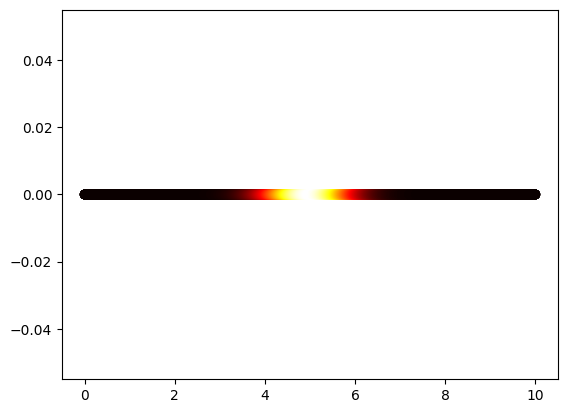

In [2]:
# =============
# TEMPERATURA INICIAL DE LA BARRA

L = 10
N = 10000
alpha = 1       # coeficiente de difusion termica
thickness = 50  # grosor de la linea

# Malla espacial
x = torch.linspace(0, L, N)

# Condicion inicial
u0 = torch.exp(- ((x - L/2)**2) )  # distribucion Gaussiana de temperatura

# Scatter plot con colores segun la temperatura
plt.figure(dpi=100)
plt.scatter(x, np.zeros_like(x), c=u0.numpy(), cmap='hot', s=thickness, edgecolors='none')

In [3]:
# =============
# DEFINICION DEL MODELO

def gradients(y, x):
    grads, = torch.autograd.grad(y, x, grad_outputs=y.data.new(y.shape).fill_(1), create_graph=True)
    return grads

class Sine(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return torch.sin(x)

# Parametros fisicos y de entrenamiento
alpha = 1            # coeficiente de difusion termica
L = 10               # dominio [0,10] en x
T_MAX = 0.1          # tiempo maximo
N_STEPS = 2500       # numero de iteraciones de entrenamiento
N_COLLOC = 25000     # numero de muestras para la PDE
N_BC = 25000         # numero de muestras para la condicion inicial y de frontera

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definicion de la MLP para approximar Psi(x,y,t)
class HEAT(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, layers[0]),
            Sine(),
            *sum([[nn.Linear(layers[i], layers[i+1]), Sine()]
                  for i in range(len(layers)-1)], []),
            nn.Linear(layers[-1], 1)
        )
    def forward(self, x):
        return self.net(x)

# Inicializar red, optimizador y scheduler
mlp = HEAT([300,300,300,300,300,300,300,300]).to(device)                            
mse = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                milestones=[2500, 5000, 7500, 10000, 20000], gamma=0.25)

print(f"Modelo inicializado correctamente en {device}.")

Modelo inicializado correctamente en cuda.


In [ ]:
# =============
# BUCLE DE ENTRENAMIENTO

# Parametros
EXTRA_EPOCHS = 10
lambda_ic    = 10
lambda_bc    = 10
model_path   = 'models/heat2D/sin3/heat2D'
os.makedirs(model_path, exist_ok=True)

# Carga de checkpoint previo
if os.path.exists(f"{model_path}.pth"):
    ckpt = torch.load(f"{model_path}.pth", map_location=device)
    mlp.load_state_dict(ckpt['model_state_dict'])
    # optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    # scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch   = ckpt['epoch']
    print(f"Cargado checkpoint de la época {start_epoch-1:02d}.")
else:
    start_epoch   = 1
    print("No hay checkpoint previo. Empezando desde epoch 01.")

N_EPOCHS = start_epoch + EXTRA_EPOCHS

for epoch in range(start_epoch, N_EPOCHS):
    mlp.train()
    epoch_loss = 0.0

    # Bucle con tqdm
    loop = tqdm(range(1, N_STEPS+1),
                desc=f"Epoch {epoch:02d}",
                unit="step",
                delay=0.1,
                total=N_STEPS)

    for step in loop:
        import math
        u = torch.rand(N_COLLOC, 1, device=device)
        v = torch.rand(N_COLLOC, 1, device=device)

        # muestreo uniforme en coordenadas baricéntricas.
        mask = (u + v) > 1.0
        u[mask] = 1.0 - u[mask]
        v[mask] = 1.0 - v[mask]

        V1 = torch.tensor([L, 0.0], device=device)
        V2 = torch.tensor([L / 2.0, (math.sqrt(3) / 2.0) * L], device=device)

        coords = u * V1 + v * V2

        # Separamos en x y y
        x = coords[:, 0:1]    # [N_COLLOC, 1]
        y = coords[:, 1:1+1]  # [N_COLLOC, 1]

        t = torch.rand(N_COLLOC, 1, device=device) * T_MAX  # [N_COLLOC, 1]
        X = torch.cat([x, y, t], dim=1).requires_grad_(True)  # [N_COLLOC, 3]

        u_pred = mlp(X)[:, 0].unsqueeze(1)  # [N_COLLOC, 1]
        grads = gradients(u_pred, X)       # grads[:, 0] = ∂u/∂x, grads[:, 1] = ∂u/∂y, grads[:, 2] = ∂u/∂t
        u_x = grads[:, 0].unsqueeze(1)     # [N_COLLOC, 1]
        u_y = grads[:, 1].unsqueeze(1)     # [N_COLLOC, 1]
        u_t = grads[:, 2].unsqueeze(1)     # [N_COLLOC, 1]

        grads_x = gradients(u_x, X)        # grads_x[:, 0] = ∂(∂u/∂x)/∂x = ∂²u/∂x²
        u_xx = grads_x[:, 0].unsqueeze(1)  # [N_COLLOC, 1]

        grads_y = gradients(u_y, X)        # grads_y[:, 1] = ∂(∂u/∂y)/∂y = ∂²u/∂y²
        u_yy = grads_y[:, 1].unsqueeze(1)  # [N_COLLOC, 1]

        loss_pde = mse(u_t, alpha * (u_xx + u_yy))


        u0 = torch.rand(N_BC, 1, device=device)
        v0 = torch.rand(N_BC, 1, device=device)
        mask0 = (u0 + v0) > 1.0
        u0[mask0] = 1.0 - u0[mask0]
        v0[mask0] = 1.0 - v0[mask0]
        coords0 = u0 * V1 + v0 * V2     # [N_BC, 2]
        x0 = coords0[:, 0:1]            # [N_BC, 1]
        y0 = coords0[:, 1:1+1]          # [N_BC, 1]
        t0 = torch.zeros(N_BC, 1, device=device)  # Todos en t = 0

        xc = L / 2.0
        yc = (math.sqrt(3) / 6.0) * L
        u0_true = torch.exp(-(((x0 - xc) ** 2 + (y0 - 2*yc) ** 2)))  # [N_BC, 1]

        X0 = torch.cat([x0, y0, t0], dim=1).requires_grad_(True)  # [N_BC, 3]
        u0_hat = mlp(X0)[:, 0].unsqueeze(1)                       # [N_BC, 1]

        loss_ic = lambda_ic * mse(u0_hat, u0_true)


        # Seleccionamos aleatoriamente para cada punto qué arista corresponde
        edges = torch.randint(0, 3, (N_BC,), device=device)  # 0, 1 o 2

        # Generamos un parámetro s
        s_bc = torch.rand(N_BC, 1, device=device)

        # Inicializamos tensores para las coordenadas de frontera
        x_b = torch.zeros(N_BC, 1, device=device)
        y_b = torch.zeros(N_BC, 1, device=device)

        mask_e0 = (edges == 0)
        x_b[mask_e0] = L * s_bc[mask_e0]
        y_b[mask_e0] = 0.0

        mask_e1 = (edges == 1)
        x_b[mask_e1] = L - s_bc[mask_e1] * (L / 2.0)
        y_b[mask_e1] = s_bc[mask_e1] * (math.sqrt(3) / 2.0) * L

        mask_e2 = (edges == 2)
        x_b[mask_e2] = (L / 2.0) * (1.0 - s_bc[mask_e2])
        y_b[mask_e2] = (L * (math.sqrt(3) / 2.0)) * (1.0 - s_bc[mask_e2])

        t_b = torch.rand(N_BC, 1, device=device) * T_MAX  # [N_BC, 1]
        Xb = torch.cat([x_b, y_b, t_b], dim=1)  # [N_BC, 3]
        u_b_pred = mlp(Xb)[:, 0].unsqueeze(1)  # [N_BC, 1]
        loss_bc = lambda_bc * mse(u_b_pred, torch.zeros_like(u_b_pred))

        optimizer.zero_grad()
        loss = loss_pde + loss_ic + loss_bc
        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_loss = loss.item()

        loop.set_postfix({
            "pde": f"{loss_pde.item():.2e}",
            "ic":  f"{loss_ic.item():.2e}",
            "bc":  f"{loss_bc.item():.2e}"
        })

    avg_epoch_loss = epoch_loss / N_STEPS
    print(f"Epoch {epoch:02d} concluida — avg loss: {avg_epoch_loss:.3e} — lr: {optimizer.param_groups[0]['lr']}")

    # Guardar checkpoint de la epoca
    checkpoint_path = f"{model_path}_{epoch:02d}.pth"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': mlp.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss_pde': loss_pde,
        'loss_ic': loss_ic/lambda_ic,
        'loss_bc': loss_bc/lambda_bc
    }, checkpoint_path)

    # Guardar checkpoint general
    checkpoint_path = f"{model_path}.pth"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': mlp.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
    }, checkpoint_path)

print("Entrenamiento completado.")

No hay checkpoint previo. Empezando desde epoch 01.


Epoch 01:   4%|▍         | 95/2500 [00:20<08:49,  4.55step/s, pde=1.55e-02, ic=5.18e-02, bc=1.04e-02]

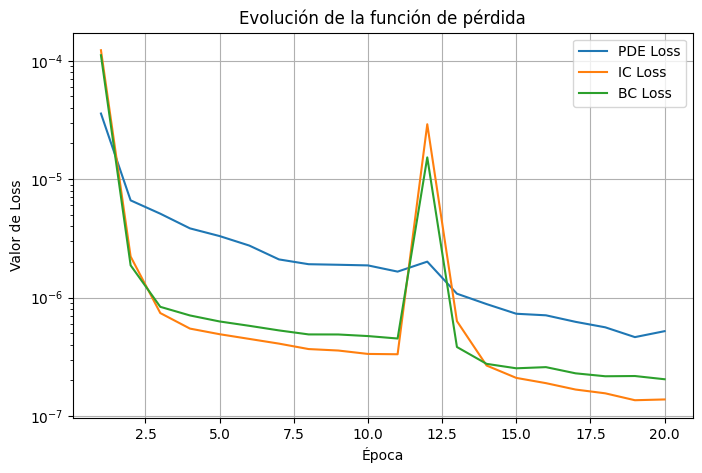

In [ ]:
# =============
# REPRESENTACION DE LA EVOLUCION DEL ERROR

# Definir ruta y buscar archivos de checkpoint
model_path   = 'models/heat2D/sin/heat2D'
checkpoint_pattern = f"{model_path}_*.pth"
checkpoint_files = sorted(glob.glob(checkpoint_pattern))

# Preparar listas para almacenar datos
epochs    = []
loss_pde  = []
loss_ic   = []
loss_bc   = []

# Recorrer cada archivo y extraer la información
device = 'cpu'
for ckpt_file in checkpoint_files:
    ckpt = torch.load(ckpt_file, map_location=device)
    epoch_num = ckpt['epoch'] - 1
    epochs.append(epoch_num)
    loss_pde.append(ckpt['loss_pde'].item())
    loss_ic.append(ckpt['loss_ic'].item())
    loss_bc.append(ckpt['loss_bc'].item())

# Graficar las curvas de perdida
plt.figure(figsize=(8, 5))
plt.yscale('log')
plt.plot(epochs, loss_pde, label='PDE Loss')
plt.plot(epochs, loss_ic,  label='IC Loss')
plt.plot(epochs, loss_bc,  label='BC Loss')
plt.xlabel('Época')
plt.ylabel('Valor de Loss')
plt.title('Evolución de la función de pérdida')
plt.legend()
plt.grid(True)
plt.show()

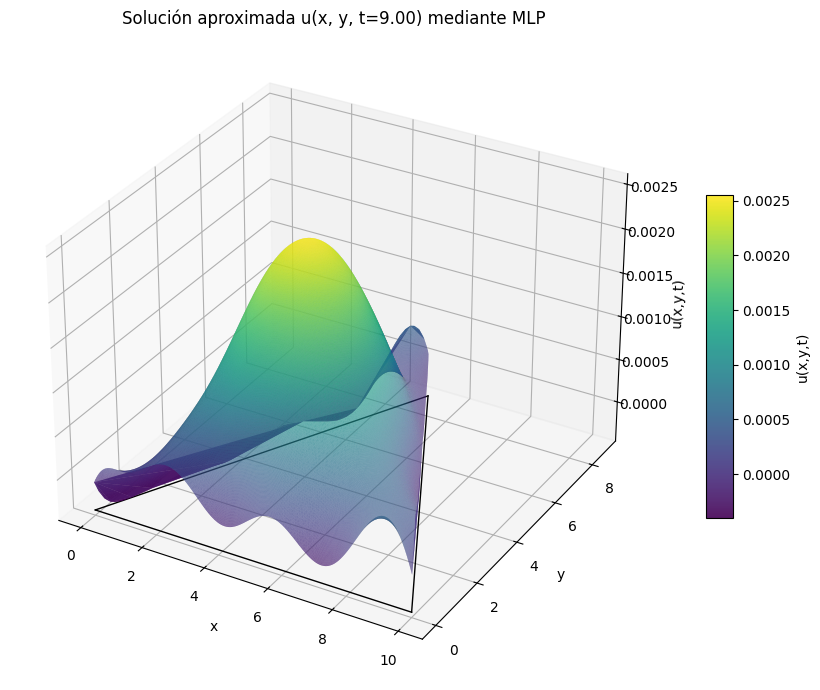

In [ ]:
# =============
# REPRESENTACION DE LA SOLUCION MLP

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------------------------
# ADAPTACIÓN PARA REPRESENTAR U(x,y,t) EN UN TRIÁNGULO
# ---------------------------------------------

# Parámetros (deben coincidir con los que usaste en el entrenamiento)
# N controla la resolución de la malla sobre el recuadro que contiene al triángulo.
# Es conveniente que N no sea demasiado grande para no saturar memoria.
N = 100          # Resolución por eje (aprox. 250k puntos totales antes de filtrar)
L = L            # Lado del triángulo (mismo L que en el entrenamiento)
T_MAX = T_MAX    # Tiempo máximo entrenado en tu PDE
mlp.eval()       # Ponemos el modelo en modo evaluación
mlp.cpu()        # Movemos la red a CPU para la inferencia (si estaba en GPU)

for t_plot in range(0, T_MAX+1, 2):
    # 1. Definimos el triángulo equilátero en el plano XY.
    #    Vértices: V0 = (0, 0), V1 = (L, 0), V2 = (L/2, sqrt(3)/2 * L).
    t_plot = t_plot / 100
    # 2. Creamos una malla rectangular suficientemente fina que cubra [0,L]×[0,L].
    x_lin = np.linspace(0.0, L, N)   # N puntos equiespaciados en [0, L]
    y_lin = np.linspace(0.0, L, N)
    Xg, Yg = np.meshgrid(x_lin, y_lin)  # Malla completa de NxN puntos

    # 3. Filtramos (Xg, Yg) para quedarnos solo con los puntos que estén dentro del triángulo.
    #    Para un triángulo equilátero de vértices (0,0), (L,0), (L/2, h), con h = sqrt(3)/2 * L,
    #    las desigualdades que definen el interior son:
    #      (i)   y >= 0
    #      (ii)  y <= sqrt(3) * x        [línea V0→V2]
    #      (iii) y <= -sqrt(3) * (x - L) [línea V1→V2]
    h = (np.sqrt(3) / 2.0) * L
    mask_interior = (
        (Yg >= 0.0)
        & (Yg <= np.sqrt(3) * Xg)
        & (Yg <= -np.sqrt(3) * (Xg - L))
    )

    # 4. Obtenemos los puntos (x,y) dentro del triángulo
    X_pts = Xg[mask_interior]  # Vector columna de coordenadas x
    Y_pts = Yg[mask_interior]  # Vector columna de coordenadas y

    # 5. Elegimos un tiempo fijo t_plot para la representación 3D.
    #    Por ejemplo, el tiempo final T_MAX (puede usarse también otro instante).
    # t_plot = 0.5
    T_pts = np.full_like(X_pts, t_plot)  # Vector columna de tiempos idénticos

    # 6. Construimos el tensor de entrada para la red: (x, y, t_plot) para cada punto.
    #    Concatenamos en un arreglo de forma [num_puntos_interior, 3].
    XYT = np.stack([X_pts, Y_pts, T_pts], axis=1)   # shape = [num_puntos, 3]
    inp = torch.from_numpy(XYT).float().requires_grad_(True)  # Tensor torch

    # 7. Evaluamos la red sobre esos puntos (sin calcular gradientes para ahorrar memoria).
    with torch.no_grad():
        # La red mlp debe estar definida para tomar 3 entradas y devolver 1 salida: u(x,y,t).
        u_pred_flat = mlp(inp).squeeze().cpu().numpy()  # Vector de predicciones

    # 8. Para graficar una superficie irregular en 3D sobre un conjunto de puntos no estructurados,
    #    usamos plot_trisurf. Necesitamos proporcionarle las coordenadas (x, y) de cada punto
    #    y el valor z = u_pred_flat. plot_trisurf internamente hará una triangulación Delaunay.
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # 9. Graficamos la superficie sobre el triángulo
    trisurf = ax.plot_trisurf(
        X_pts,                # Coordenadas x de los puntos
        Y_pts,                # Coordenadas y de los puntos
        u_pred_flat,          # Altura z = u(x,y,t_plot)
        cmap='viridis',       # Mapa de colores elegido (puede cambiarse)
        linewidth=0.0,
        antialiased=True,
        alpha=0.9
    )

    # 10. Ajustamos etiquetas y título. Nota: u(x,y,t) en título.
    ax.set_title(f'Solución aproximada u(x, y, t={t_plot:.2f}) mediante MLP')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(x,y,t)')
    ax.view_init(elev=45, azim=270)  # Ajustar ángulo de vista

    # 11. Opcional: podemos dibujar las líneas de los lados del triángulo
    #     para que se note el contorno del dominio
    #     Lado V0→V1 (y=0)
    ax.plot([0, L], [0, 0], [np.min(u_pred_flat), np.min(u_pred_flat)], color='k', linewidth=1)
    #     Lado V1→V2
    ax.plot([L, L/2], [0, h], [np.min(u_pred_flat), np.min(u_pred_flat)], color='k', linewidth=1)
    #     Lado V2→V0
    ax.plot([L/2, 0], [h, 0], [np.min(u_pred_flat), np.min(u_pred_flat)], color='k', linewidth=1)

    # 12. Barra de color para interpretar alturas
    fig.colorbar(trisurf, ax=ax, shrink=0.5, aspect=12, label='u(x,y,t)')

    plt.tight_layout()
    plt.show()

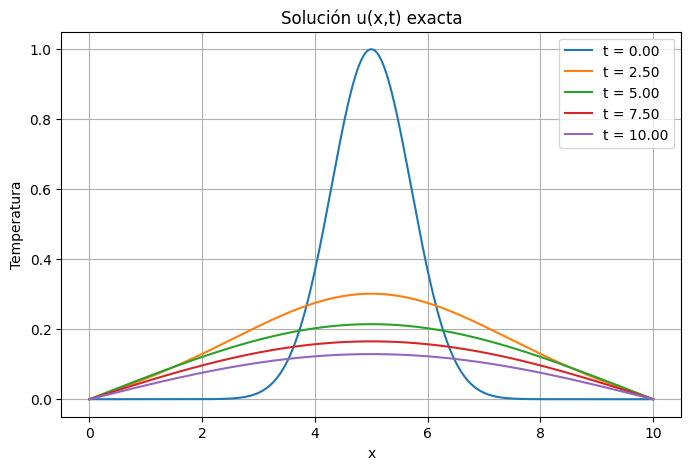

In [ ]:
from scipy.integrate import quad

# Parametros
L = 10.0
Nx = 10000
alpha = 1
x = np.linspace(0, L, Nx)
N_terms = 50

def u0(y):
    return np.exp(-y**2)

def compute_bn(n):
    integrand = lambda y: u0(y - L/2) * np.sin(n * np.pi * y / L)
    bn, _ = quad(integrand, 0, L)
    return (2.0 / L) * bn

b = np.array([compute_bn(n) for n in range(1, N_terms + 1)])

def heat_solution_dirichlet(x, t, N_terms=N_terms):
    u = np.zeros_like(x)
    for n in range(1, N_terms + 1):
        u += b[n-1] * np.sin(n * np.pi * x / L) * np.exp(- (n * np.pi / L)**2 * alpha * t)
    return u

# Parametros temporales
tf = 10.0
n_snapshots = 5

tiempos_snapshot = np.linspace(0, tf, n_snapshots)
solutions_snap = [heat_solution_dirichlet(x, t) for t in tiempos_snapshot]

# Plot unico con todas las curvas
plt.figure(figsize=(8, 5))
for t, perfil in zip(tiempos_snapshot, solutions_snap):
    plt.plot(x, perfil, label=f't = {t:.2f}')

plt.xlabel('x')
plt.ylabel('Temperatura')
plt.title('Solución u(x,t) exacta')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

t = np.linspace(0, tf, Nt)
indices = [0, Nt//4, Nt//2, 3*Nt//4, -1]

# Calculo del MSE solo en estos indices
for i in indices:
    ti  = t[i]
    mse = mean_squared_error(
        heat_solution_dirichlet(x, ti),
        U[i]
    )
    print(f"t = {ti:.2f}, MSE = {mse:.3e}")

NameError: name 'Nt' is not defined